# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [ ]:
import sys
sys.path.append('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/')
import functions  
import importlib
importlib.reload(functions)  # Reload to reflect changes
from functions import *  # Now import updated functions

#add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read data

In [ ]:
np.random.seed(1002)
random.seed(0)
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO2 content in the raw gas (preheater outlet)'] > 200) & (ALL['CO2 content in the raw gas (preheater outlet)'] < 350)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO2 content in the raw gas (preheater outlet)']]
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)

# All model training (CO2)

### SVR works best

In [3]:
titles = ['Linear regression', 'Lasso', 'Ridge', 'Elastic net', 'Random forest', 'XGBoost', 'SVR', 'GPR', 'NN']

In [5]:
train_scores = []
val_scores = []
test_scores = []

# LR

LinearRegression()

Avg Training:  R^2 = 0.66, MAE = 5.49, MAPE = 2.23%
Avg Val:  R^2 = 0.66, MAE = 5.5, MAPE = 2.23%
Test 0.66 5.45 2.21


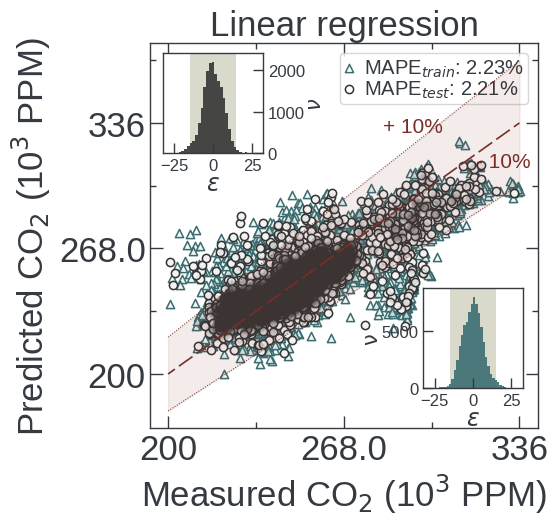

In [26]:
best_regressor = LinearRegression()
best_regressor.fit(X_train, y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[0]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[0],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Lasso

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.414e+06, tolerance: 9.727e+02


[CV] END ........................................alpha=1e-05; total time=   3.0s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.417e+03, tolerance: 9.727e+02


[CV] END .......................................alpha=0.0001; total time=   2.9s
[CV] END ........................................alpha=0.001; total time=   2.3s
[CV] END ..........................................alpha=0.1; total time=   0.9s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.970e+06, tolerance: 1.287e+03


GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 14.5903 s
System CPU time  : 0.1000 s
Total CPU time   : 14.6903 s
Wall clock time  : 15.1565 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.51%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32


{'alpha': 1e-05}

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.468e+06, tolerance: 9.562e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.512e+06, tolerance: 9.647e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.501e+06, tolerance: 9.670e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.388e+06, tolerance: 9.742e+02
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names
X has feature names, but Lasso was fitted without feature names


Avg Training:  R^2 = 0.66, MAE = 5.49, MAPE = 2.23%
Avg Val:  R^2 = 0.66, MAE = 5.5, MAPE = 2.23%
Test 0.66 5.45 2.21


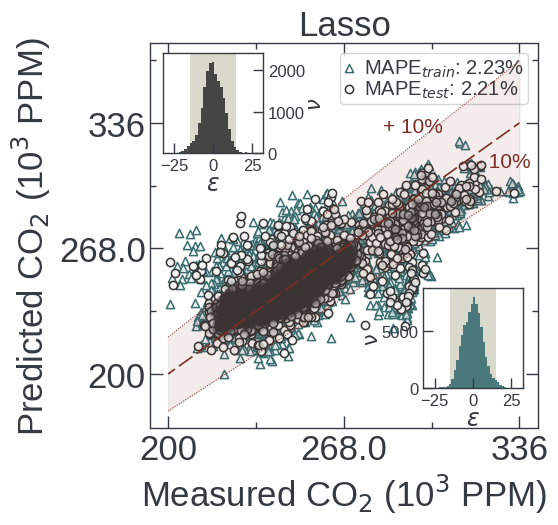

In [27]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Lasso()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
end_profiling(save_path = None, note = None)
random_search.best_params_
# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[1]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[1],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Ridge

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV] END ........................................alpha=1e-05; total time=   0.0s
[CV] END .......................................alpha=0.0001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ..........................................alpha=0.1; total time=   0.0s


{'alpha': 1e-05}

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 0.1776 s
System CPU time  : 0.0720 s
Total CPU time   : 0.2496 s
Wall clock time  : 0.6327 s

---- CPU Utilization Stats ----
Avg CPU usage    : 0.00%
Max CPU usage    : 0.00%
Logical cores    : 64
Physical cores   : 32
Avg Training:  R^2 = 0.66, MAE = 5.49, MAPE = 2.23%
Avg Val:  R^2 = 0.66, MAE = 5.5, MAPE = 2.23%


X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names
X has feature names, but Ridge was fitted without feature names


Test 0.66 5.45 2.21


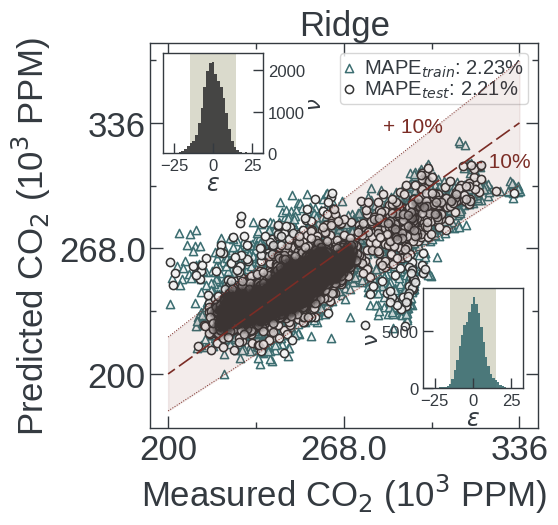

In [28]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = Ridge()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[2]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[2],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# Elastic net

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
Fitting 1 folds for each of 4 candidates, totalling 4 fits


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.524e+06, tolerance: 9.727e+02


[CV] END ........................................alpha=1e-05; total time=   2.9s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.390e+05, tolerance: 9.727e+02


[CV] END .......................................alpha=0.0001; total time=   2.9s
[CV] END ........................................alpha=0.001; total time=   2.5s
[CV] END ..........................................alpha=0.1; total time=   0.7s


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.076e+06, tolerance: 1.287e+03


{'alpha': 1e-05}

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 15.0220 s
System CPU time  : 0.0760 s
Total CPU time   : 15.0980 s
Wall clock time  : 15.1454 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.51%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32


Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.555e+06, tolerance: 9.562e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.572e+06, tolerance: 9.647e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.567e+06, tolerance: 9.670e+02
Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.512e+06, tolerance: 9.742e+02
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names
X has feature names, but ElasticNet was fitted without feature names


Avg Training:  R^2 = 0.66, MAE = 5.49, MAPE = 2.23%
Avg Val:  R^2 = 0.66, MAE = 5.5, MAPE = 2.23%
Test 0.66 5.45 2.21


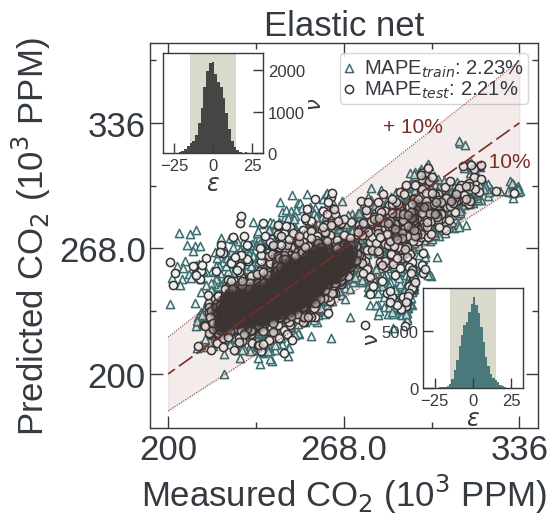

In [29]:
np.random.seed(1002)
random.seed(0)

start_profiling() 
regressor = ElasticNet()
hyperparameter_grid= {'alpha': [0.00001, 0.0001,0.001, 0.1]} 
iterations = 4
best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
                                                       iterations = 4, verbose= 2)
random_search.best_params_
end_profiling(save_path = None, note = None)

# save Randomsearch results
log_search_space(random_search.cv_results_, file_note = None,log_file_path= None)
# k fold cross validation
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train)
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[3]}_parity.pdf'
# parity plot
test_results = parity_train_test(best_regressor, titles[3],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

# Random forest

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
# hyperparameter_grid = {
#     "n_estimators": [ 600, 800],
#     "max_depth": [24, 25],        # None = grow until pure
#     "min_samples_split": [16],
#     "min_samples_leaf": [ 16],
#     "max_features": [0.4],
#     "ccp_alpha": [0.0],
#     "bootstrap": [True]
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, np.ravel(y_train), # ravel for randomforest
#                                                        iterations = iterations, verbose= 1)
# random_search.best_params_
# end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/RF_CO2_RanSearchCV.txt',
#               note = 'RandomSearchCV for plant 1 Rf co')
# save_model(best_regressor,
#            model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/RF_co2_best.pkl')

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/co2_RF.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
# fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[4]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[4],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
# train_scores.append(tuple(avg_train_results)) 
# val_scores.append(tuple(avg_val_results)) 
# test_scores.append(tuple(test_results))

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().


Avg Training:  R^2 = 0.95, MAE = 1.36, MAPE = 0.55%
Avg Val:  R^2 = 0.92, MAE = 1.8, MAPE = 0.72%
Test 0.93 1.68 0.67


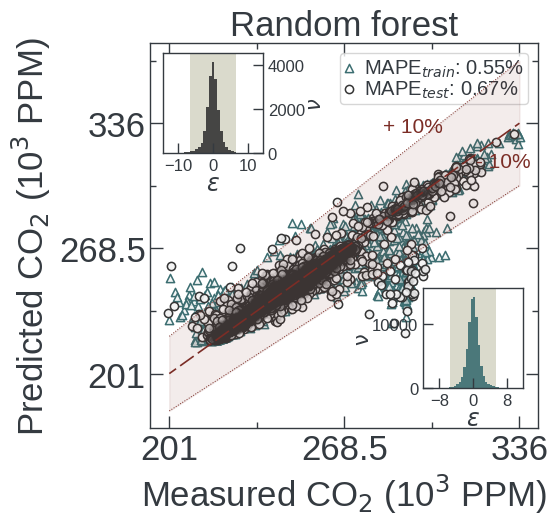

In [30]:
np.random.seed(1002)
random.seed(0)
best_regressor = RandomForestRegressor(n_estimators  = 1000,  min_samples_split  = 4,  min_samples_leaf  = 8, 
                                  max_features  = 0.6,  max_depth  = 24,  ccp_alpha  = 0.001, 
                                  bootstrap  = True, random_state=42, n_jobs=-1).fit(X_train,y_train)

avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[4]}_parity.pdf'
# train_test_score(best_regressor, X_train, X_test, y_train, y_test)
test_results = parity_train_test(best_regressor, titles[4],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results))
test_scores.append(tuple(test_results))

# XGboost

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# regressor = XGBRegressor(random_state=42, tree_method='gpu_hist', n_jobs=-1)
# hyperparameter_grid = {
#     "n_estimators": [200, 400, 600, 800],            # more trees but slower learning
#     "max_depth": [3, 4, 5, 6, 7],                   # shallower trees → less overfitting
#     "min_child_weight": [5, 7, 9, 11],               # larger = less complex splits
#     "subsample": [0.6, 0.7, 0.8, 0.9],               # row sampling
#     "colsample_bytree": [0.6, 0.7, 0.8, 0.9],        # feature sampling
#     "learning_rate": [0.01, 0.02, 0.03, 0.05],       # slower learning → needs more trees
#     "reg_lambda": [5, 7, 9, 11],                     # L2 regularization
#     "reg_alpha": [3, 5, 7, 9]                        # L1 regularization
# }
# iterations =100
# best_regressor,random_search = RandomSearchCV_pipeline(regressor, hyperparameter_grid, X_train, y_train, 
#                                                        iterations = iterations, verbose= 2)
# random_search.best_params_
# end_profiling(save_path = None, note = None)

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = 'palnt2 CO XGBoost',log_file_path= '/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant2/XGboost.txt')
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[5],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

# Best model stats

GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 347 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 18.5542 s
System CPU time  : 0.1920 s
Total CPU time   : 18.7462 s
Wall clock time  : 19.1756 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.52%
Max CPU usage    : 1.59%
Logical cores    : 64
Physical cores   : 32
Model size: 33.79 MB
Avg Training:  R^2 = 1.0, MAE = 0.45, MAPE = 0.18%
Avg Val:  R^2 = 0.95, MAE = 1.45, MAPE = 0.58%
Test 0.96 1.34 0.54


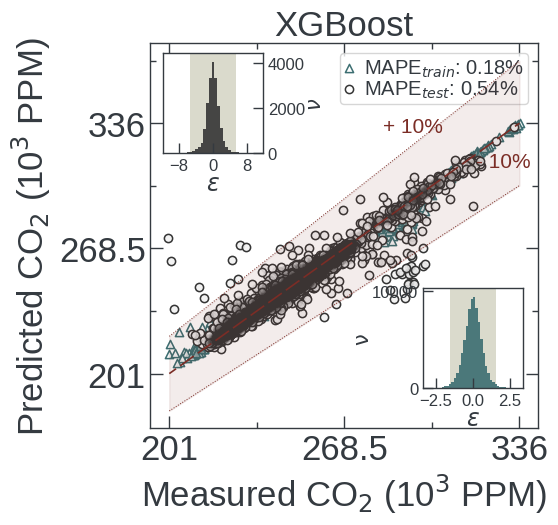

In [ ]:
# manually tuned model
np.random.seed(1002)
random.seed(0)

start_profiling() 
# best_regressor = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co2/plant_1_co2.pkl')
best_regressor = XGBRegressor(
subsample=0.9,
reg_lambda=3,  # Reduced for less restriction
reg_alpha=3,
n_estimators=1500,  # Slightly increased
min_child_weight=8,  # Reverted to original
max_depth=10,  # Back to original
learning_rate=0.03,  # Keeping same for stable updates
colsample_bytree=0.6,  # Back to original
random_state=42,
tree_method='gpu_hist',
n_jobs=-1
).fit(X_train,y_train)

end_profiling()

model_size('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/all_models_train/general_models/co2/co2_full_range.pkl')
avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) 
fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[5]}_parity.pdf'
test_results = parity_train_test(best_regressor, titles[5],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path)
train_scores.append(tuple(avg_train_results))
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))


# NN

In [ ]:
# np.random.seed(1002)
# random.seed(0)

# start_profiling() 
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= MLPRegressor(),
#         transformer=StandardScaler()))
# ])
# hyperparameter_grid = {
#     'hidden_layer_sizes': [
#         (64,), (128,), (256,),          # Single layer
#         (64, 32), (128, 64), (256, 128), # Two layers
#         (128, 64, 32), (64, 32, 16)      # Three layers (only for more data)
#     ],
#     'activation': ['relu'],
#     'learning_rate_init': [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
#     'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
#     'batch_size': [16, 32, 64, 128],
#     'solver': ['adam'],  # 'lbfgs' works better for small datasets, 'adam' for large
#     'early_stopping': [True],  # Keep fixed if you're using validation
#     'n_iter_no_change': [20],
#     'validation_fraction': [0.2],
#     'max_iter': [500],
#     'random_state': [42], 
#     'verbose': [False]
# }
# iterations =150
# best_regressor,random_search = RandomSearchCV_pipeline(pipeline, flatten_grid(hyperparameter_grid), X_train, y_train,  # ravel for NN
#                                                        iterations = iterations, verbose= 1)

# random_search.best_params_
# end_profiling(save_path = '/home/m3rg2000/Junaid_temporary/saved_data/Time_cpu_stats/plant1/NN_co_rand_SearchCV.txt',
#               note = 'RandomSearchCV for plant 1 co nn')
# save_model(best_regressor,
#            model_path = f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co_best.pkl')

# # save Randomsearch results
# log_search_space(random_search.cv_results_, file_note = None,log_file_path = "/home/m3rg2000/Junaid_temporary/HYP_Opt_Logs/predict/plant1/co_nn.txt")
# # k fold cross validation
# avg_train_results, avg_val_results = k_fold_scores(best_regressor, X_train, y_train) fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[0]}_parity.pdf'
# # parity plot
# test_results = parity_train_test(best_regressor, titles[8],'CO$_{2}$ (10$^{3}$ PPM)', X_train, X_test, y_train, y_test,avg_train_results,y, fig_path = fig_path) train_scores.append(tuple(avg_train_results)) val_scores.append(tuple(avg_val_results)) test_scores.append(tuple(test_results))

Iteration 1, loss = 0.09487319
Validation score: 0.862115
Iteration 2, loss = 0.06415852
Validation score: 0.869993
Iteration 3, loss = 0.05557979
Validation score: 0.882659
Iteration 4, loss = 0.05138423
Validation score: 0.894415
Iteration 5, loss = 0.04793062
Validation score: 0.894804
Iteration 6, loss = 0.04613950
Validation score: 0.896683
Iteration 7, loss = 0.04482096
Validation score: 0.904648
Iteration 8, loss = 0.04311001
Validation score: 0.907392
Iteration 9, loss = 0.04204857
Validation score: 0.903127
Iteration 10, loss = 0.04158255
Validation score: 0.909757
Iteration 11, loss = 0.04135572
Validation score: 0.896798
Iteration 12, loss = 0.03969241
Validation score: 0.902821
Iteration 13, loss = 0.03901176
Validation score: 0.912850
Iteration 14, loss = 0.03848758
Validation score: 0.911950
Iteration 15, loss = 0.03834069
Validation score: 0.910771
Iteration 16, loss = 0.03664068
Validation score: 0.910218
Iteration 17, loss = 0.03756770
Validation score: 0.911037
Iterat

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.


Iteration 1, loss = 0.09385314
Validation score: 0.846423
Iteration 2, loss = 0.06329605
Validation score: 0.843932
Iteration 3, loss = 0.05595407
Validation score: 0.895122
Iteration 4, loss = 0.05012216
Validation score: 0.889294
Iteration 5, loss = 0.04642837
Validation score: 0.897405
Iteration 6, loss = 0.04517368
Validation score: 0.899348
Iteration 7, loss = 0.04326141
Validation score: 0.907544
Iteration 8, loss = 0.04289687
Validation score: 0.898794
Iteration 9, loss = 0.04256291
Validation score: 0.906320
Iteration 10, loss = 0.04209976
Validation score: 0.908404
Iteration 11, loss = 0.04041500
Validation score: 0.914428
Iteration 12, loss = 0.03919092
Validation score: 0.904182
Iteration 13, loss = 0.03970020
Validation score: 0.911047
Iteration 14, loss = 0.03851663
Validation score: 0.917289
Iteration 15, loss = 0.03794318
Validation score: 0.909925
Iteration 16, loss = 0.03936112
Validation score: 0.923901
Iteration 17, loss = 0.03640912
Validation score: 0.921453
Iterat

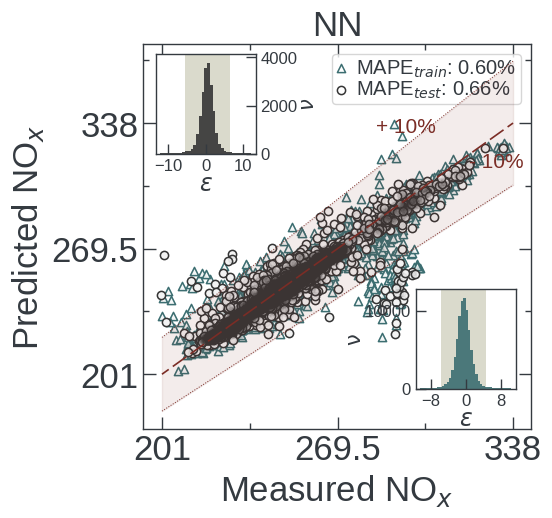

In [ ]:
# train time 20 mins
np.random.seed(1002)
random.seed(0)

# regressor = MLPRegressor(
# early_stopping = True ,             
# n_iter_no_change = 20,
# random_state = 42,
# activation = 'relu',                  
# solver = 'adam',                    
# max_iter = 100, 
# verbose = True,
 
# hidden_layer_sizes = (256, 128, 64),  
# learning_rate_init = 0.003 ,          
# batch_size = 64,                    
# alpha = 0.0005 
# )
# pipeline = Pipeline([      
#     ('scaler_X', StandardScaler()), 
#     ('model', TransformedTargetRegressor(
#         regressor= regressor,
#         transformer=StandardScaler()))
# ])
# pipeline.fit(X_train, y_train)

# save_model(pipeline,
#            model_path = '/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co2_best.pkl')
pipeline = load_model('/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/NN_co2_best.pkl')

avg_train_results, avg_val_results = k_fold_scores(pipeline, X_train, y_train) 

fig_path = f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/plant_compare/plant1/co2/{titles[8]}_parity.pdf'
test_results = parity_train_test(pipeline, titles[8],'NO$_{x}$', X_train, X_test, y_train, y_test, avg_train_results,y, fig_path = fig_path) 
train_scores.append(tuple(avg_train_results)) 
val_scores.append(tuple(avg_val_results)) 
test_scores.append(tuple(test_results))

In [9]:
# train_scores
# val_scores
# test_scores

train_sc = [(0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.66, 5.49, 2.23),
 (0.95, 1.36, 0.55),
 (1.0, 0.45, 0.18),
 (0.96, 1.49, 0.6)]

val_sc = [(0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.66, 5.5, 2.23),
 (0.92, 1.8, 0.72),
 (0.95, 1.45, 0.58),
 (0.93, 1.7, 0.68)]


test_sc = [(0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.66, 5.45, 2.21),
 (0.93, 1.68, 0.67),
 (0.96, 1.34, 0.54),
 (0.94, 1.65, 0.66)]

In [ ]:
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_train_co.pkl", "wb") as f:  
    pickle.dump(train_sc, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_val_co.pkl", "wb") as f:  
    pickle.dump(val_sc, f)
    
with open("/home/m3rg2000/Junaid_temporary/saved_data/general/scores_plant1_test_co.pkl", "wb") as f:  
    pickle.dump(test_sc, f)
 